In [4]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

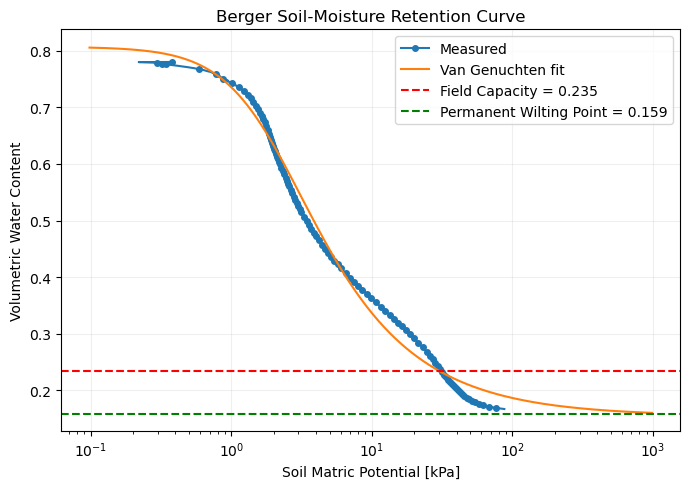

In [ ]:
#Berger Soil Van Genuchten curve fitting
data = pd.read_excel(
    r'C:\Users\Josh.Gottlieb\OneDrive - Geosyntec\Documents\SourceCode\Photo3-Plant-Salinity-Traits\sample_data\Soil\Berger_Sample_points_removed.xlsx',
    sheet_name='Measurements'
)


# --- Parameters ---
## Note: s in the code is saturation (0-1) on a pore volume basis. Theta values here are on a soil volume basis
volume     = 250      # cm^3
dry_weight = 34.2    # g
n          = 1.768
alpha      = 0.0502   # 1/cm
th_r       = 0.155 # Residual water content Volumetric Water Content (should be very similar to SH)
th_s        = 0.807 # Porosity 
m          = 1 - 1/n  # standard VG shape parameter
SH = # s when SWP is -10 MPa

# --- Measured data ---
mass          = data['Net weight [g]']
lower_tension = data['Tension Bottom [kPa]']
upper_tension = data['Tension Top [kPa]']

average_tension = (lower_tension + upper_tension) / 2
vwc_retention   = (mass - dry_weight) / volume

# Convert cm H2O to kPa (1 cm H2O = 0.0980665 kPa)
h = np.logspace(0, 4, 500)  # in cm
h_kpa = h * 0.0980665  # convert to kPa
m = 1 - 1/n
van_genuchten_fit = th_r + (th_s - th_r) / (1 + (alpha * h)**n)**m

# --- Plot ---
plt.figure(figsize=(7, 5))
plt.plot(average_tension, vwc_retention, '-', marker='o', markevery=20, label='Measured', markersize=4)
plt.plot(h_kpa, van_genuchten_fit, '-', label='Van Genuchten fit')

# Convert kPa to cm H2O for VG equation
fc_tension_cm  = 30   * 10.1972
pwp_tension_cm = 1500 * 10.1972

field_capacity = th_r + (th_s - th_r) / (1 + (alpha * fc_tension_cm)**n)**m
permanent_wilting_point = th_r + (th_s - th_r) / (1 + (alpha * pwp_tension_cm)**n)**m

#plot field capacity and permanent wilting point
plt.axhline(y=field_capacity, color='r', linestyle='--', label=f'Field Capacity = {field_capacity:.3f}')
plt.axhline(y=permanent_wilting_point, color='g', linestyle='--', label=f'Permanent Wilting Point = {permanent_wilting_point:.3f}')

plt.xlabel('Soil Matric Potential [kPa]')
plt.ylabel('Volumetric Water Content')
plt.xscale('log')
plt.grid(True, alpha=0.2)
plt.title('Berger Soil-Moisture Retention Curve')
plt.legend()
plt.tight_layout()
plt.show()
def vwc_to_water_potential(vwc):
    """
    Inverse Van Genuchten: given volumetric water content(s) in PERCENT (0-100), 
    return matric potential in kPa (negative value = suction/tension).
    """
    
    # Hardcoded parameters
    th_r = 0.155
    th_s = 0.807
    alpha = 0.0502
    n = 1.768

    m = 1 - 1 / n
    vwc = np.asarray(vwc, dtype=float)
    
    # Convert percent to fraction
    vwc_fraction = vwc / 100.0
    
    # For values below residual water content, set to a very dry condition
    # This prevents nan values and gives very negative matric potential
    mask_below = vwc_fraction < th_r
    if np.any(mask_below):
        # Set to just below residual for calculation
        vwc_fraction[mask_below] = th_r * 0.99
    
    # For values above saturated, cap them
    mask_above = vwc_fraction > th_s
    if np.any(mask_above):
        vwc_fraction[mask_above] = th_s * 0.99

    Se = (vwc_fraction - th_r) / (th_s - th_r)
    h_cm = (1 / alpha) * (Se**(-1 / m) - 1) ** (1 / n)
    h_kpa = h_cm / 10.1972

    return -h_kpa
